# ============================================================================
# CINN_WS2025_Project_np
# Computational Intelligence and Neural Networks - Winter Semester 2025
# Team Members: [Add your team members' names and IDs here]
# ============================================================================

In [1]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the library to fetch datasets from UCI repository
from ucimlrepo import fetch_ucirepo 
  
# Download the breast cancer dataset (ID 17) from UCI repository
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# Extract the feature columns (X) from the dataset as a pandas DataFrame
X = breast_cancer_wisconsin_diagnostic.data.features 

# Extract the target column (y) from the dataset as a pandas DataFrame
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# Print information about the dataset (name, description, source, etc.)
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# Print details about each variable/column (name, type, role, missing values, etc.)
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [3]:
# Requirement Name: Import Libraries
# ====================================

# Import pandas library for working with tables/dataframes
import pandas as pd

# Import numpy library for mathematical operations and arrays
import numpy as np

# Import matplotlib for creating basic plots and graphs
import matplotlib.pyplot as plt

# Import seaborn for creating beautiful statistical visualizations
import seaborn as sns

# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Import tools to normalize data and encode categorical labels
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import function to create confusion matrix for evaluating predictions
from sklearn.metrics import confusion_matrix

# Import warnings library to manage warning messages
import warnings

# Turn off warning messages to keep output clean
warnings.filterwarnings('ignore')

# Set random seed to 42 so results are the same every time we run the code
np.random.seed(42)

# Print a line of 80 equal signs
print("=" * 80)

# Print the project title
print("NEURAL NETWORK FROM SCRATCH - PROJECT IMPLEMENTATION")

# Print another line of 80 equal signs
print("=" * 80)

NEURAL NETWORK FROM SCRATCH - PROJECT IMPLEMENTATION


In [4]:
# ============================================================================
# SECTION 1: DATASET SELECTION (10 marks)
# ============================================================================

# Requirement Name: Dataset Selection and Loading
# ================================================
"""
Dataset Information:
- Name: Breast Cancer Wisconsin (Diagnostic)
- Source: UCI Machine Learning Repository
- URL: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Task: Binary Classification (Malignant vs Benign)
- Real-world significance: Early detection of breast cancer is crucial for patient survival.
  This dataset helps classify tumors as malignant or benign based on cell nucleus characteristics
  from fine needle aspirate (FNA) images, supporting medical diagnosis and treatment planning.
- Why Neural Network: The dataset contains 30 continuous features with complex non-linear 
  relationships between cell nucleus characteristics. A neural network can learn these intricate
  patterns and decision boundaries that may not be easily captured by traditional linear models.
"""

# Make a copy of X so changes don't affect the original
df = X.copy()

# Add the Diagnosis column to our table
df['Diagnosis'] = y

# Print a success message
print(f"\nDataset loaded successfully!")

# Print how many rows and columns (e.g., "569, 31")
print(f"Dataset shape: {df.shape}")

# Print header
print(f"\nFirst few rows:")

# Show the first 5 rows of data
print(df.head())

# Print header
print(f"\nDataset Info:")

# Show info about columns (names, types, missing values)
print(df.info())

# Print header
print(f"\nTarget distribution:")

# Count how many of each diagnosis (e.g., B: 357, M: 212)
print(df['Diagnosis'].value_counts())


Dataset loaded successfully!
Dataset shape: (569, 31)

First few rows:
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1809             0.05883  ...     16.67   

   perimeter3   area

# ============================================================================
# SECTION 2: DATA UNDERSTANDING AND PREPROCESSING (20 marks)
# ============================================================================

# Requirement Name: Features Identification and Summary (6 marks)


In [5]:



# Create a function called generate_feature_summary
def generate_feature_summary(dataframe):
    """
    Generate comprehensive summary of dataset features including:
    - Data type, Total values, Unique values, Missing values, Sample value
    """
    # Print blank line + line of equal signs
    print("\n" + "=" * 80)
    
    # Print title
    print("FEATURE SUMMARY")
    
    # Print line of equal signs
    print("=" * 80)
    
    # Create empty list to hold info
    summary_data = []
    
    # Loop through each column name
    for col in dataframe.columns:
        
        # Add a dictionary with 7 pieces of info about this column
        summary_data.append({
            # What's the column called?
            'Feature Name': col,
            
            # What type of data? (number, text, etc.)
            'Data Type': str(dataframe[col].dtype),
            
            # How many values total?
            'Total Values': len(dataframe[col]),
            
            # How many different values?
            'Unique Values': dataframe[col].nunique(),
            
            # How many missing values?
            'Missing Values': dataframe[col].isnull().sum(),
            
            # What % is missing?
            'Missing %': f"{(dataframe[col].isnull().sum() / len(dataframe[col]) * 100):.2f}%",
            
            # Show first value as example (max 50 characters)
            'Sample Value': str(dataframe[col].iloc[0])[:50] if len(dataframe[col]) > 0 else None
        })
    
    # Turn the list into a table
    summary_df = pd.DataFrame(summary_data)
    
    # Print the table (no row numbers)
    print(summary_df.to_string(index=False))
    
    # Give back the table
    return summary_df

# Run the function on our data
feature_summary = generate_feature_summary(df)


FEATURE SUMMARY
      Feature Name Data Type  Total Values  Unique Values  Missing Values Missing % Sample Value
           radius1   float64           569            456               0     0.00%        17.99
          texture1   float64           569            479               0     0.00%        10.38
        perimeter1   float64           569            522               0     0.00%        122.8
             area1   float64           569            539               0     0.00%       1001.0
       smoothness1   float64           569            474               0     0.00%       0.1184
      compactness1   float64           569            537               0     0.00%       0.2776
        concavity1   float64           569            537               0     0.00%       0.3001
   concave_points1   float64           569            542               0     0.00%       0.1471
         symmetry1   float64           569            432               0     0.00%       0.2419
fractal_dimen

# Requirement Name: Visual Data Exploration (6 marks)



VISUAL DATA EXPLORATION


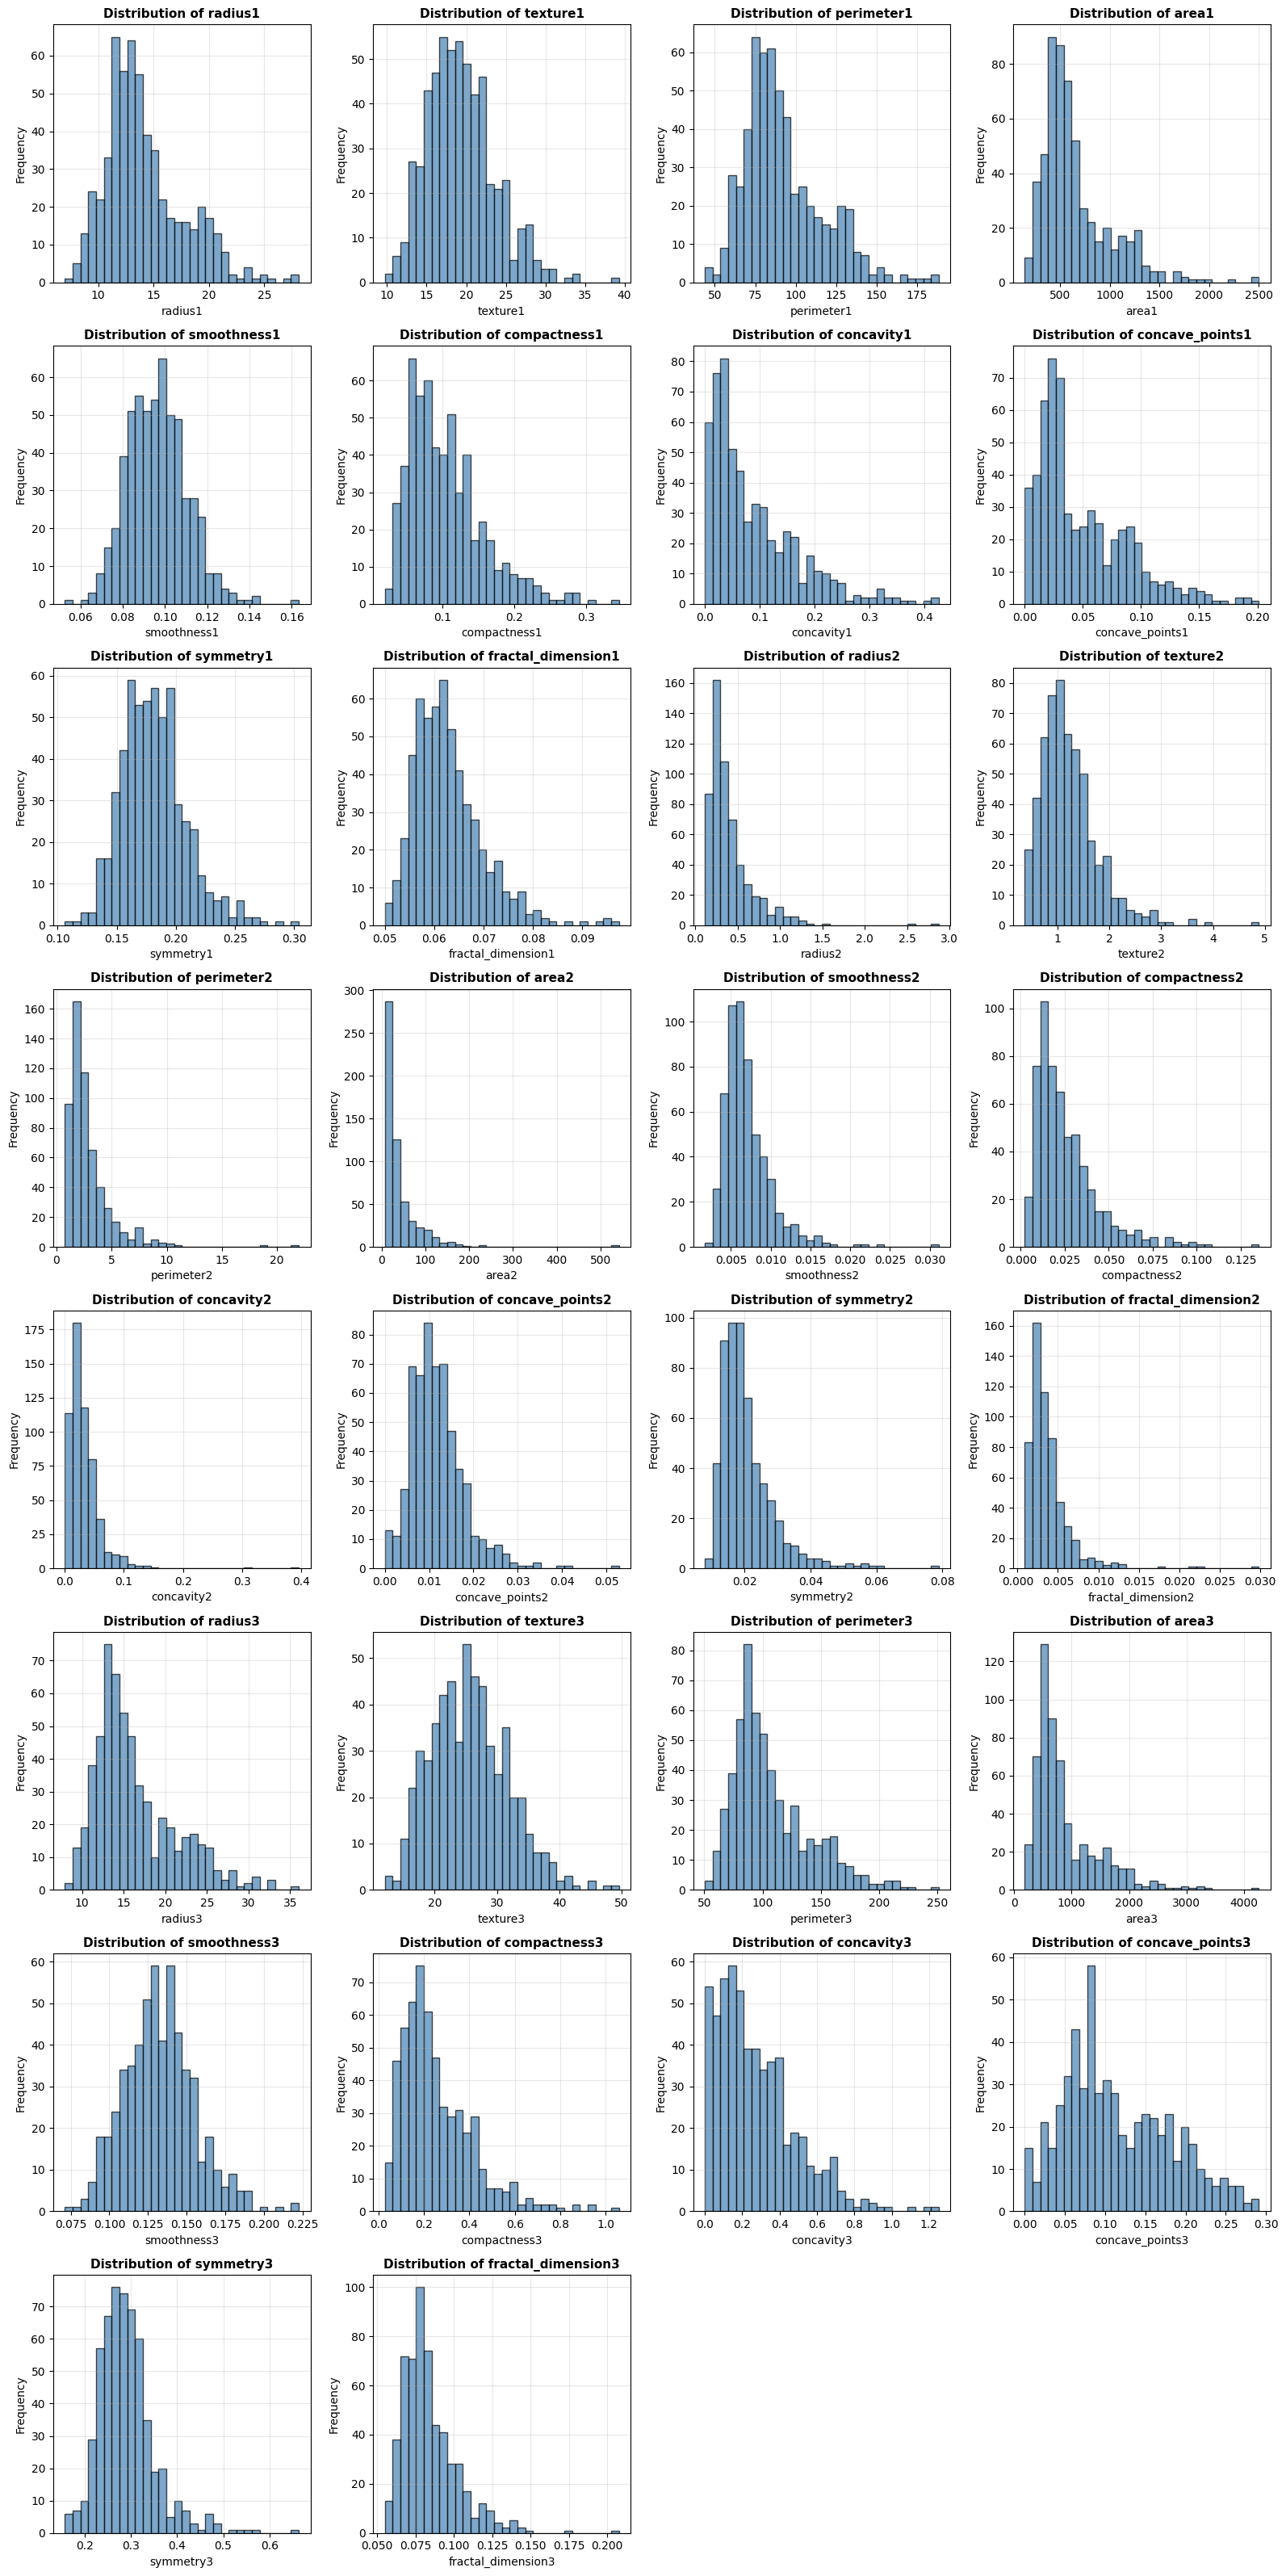

✓ Histograms generated for numerical features


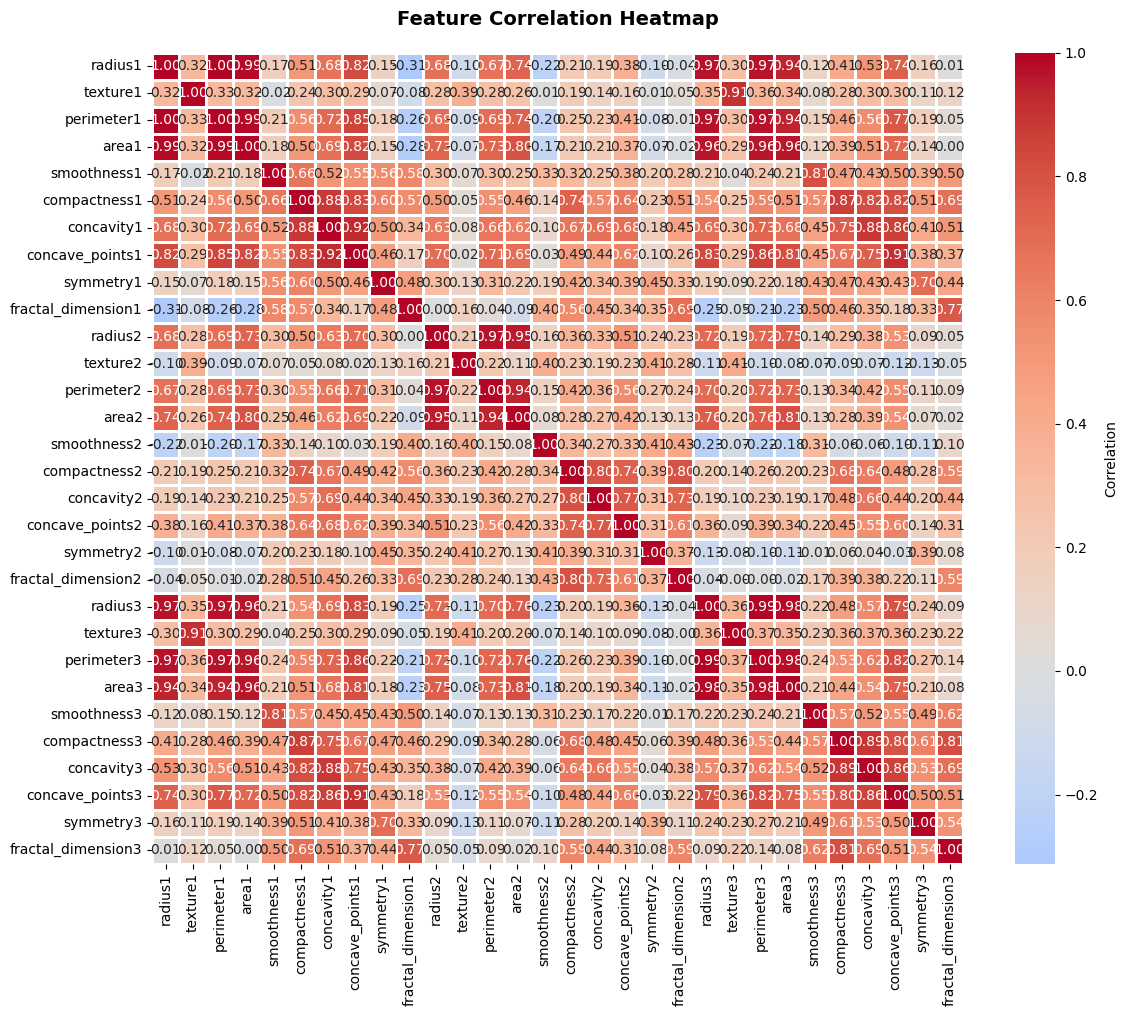

✓ Correlation heatmap generated


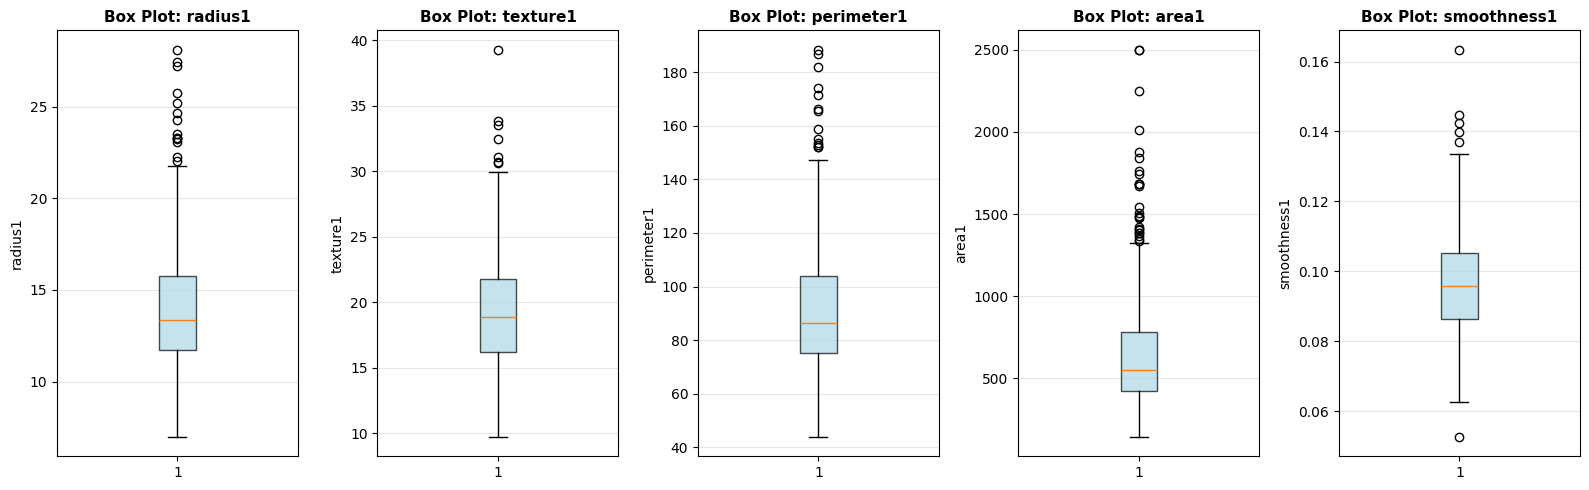

✓ Box plots generated for outlier detection


In [6]:
# Requirement Name: Visual Data Exploration (6 marks)
# ===================================================

# Create a function that takes a dataset (dataframe) and draws useful plots
def visualize_data(dataframe):
    """
    Generate visualizations to understand the dataset:
    - Histograms: show how each numeric feature is distributed
    - Correlation heatmap: show how features are related to each other
    - Box plots: help us see outliers (very large or very small values)
    """
    # Print a nice section header so it's clear in the output
    print("\n" + "=" * 80)
    print("VISUAL DATA EXPLORATION")
    print("=" * 80)
    
    # Pick only the columns that contain numbers (ignore text/categorical columns)
    numerical_cols = dataframe.select_dtypes(include=[np.number]).columns
    
    # === PART 1: HISTOGRAMS ===
    # If we have at least one numeric column, we can draw histograms
    if len(numerical_cols) > 0:
        # We don't want too many plots in one row, so use at most 4 per row
        n_cols = min(len(numerical_cols), 4)
        
        # Work out how many rows of plots we need to show all numeric columns
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
        
        # Create a grid (rows x columns) of empty plots to draw into
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        
        # Make sure 'axes' is always a simple 1D list so we can loop over it easily
        axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
        
        # Go through each numeric column one by one
        for idx, col in enumerate(numerical_cols):
            # Draw a histogram of that column's values (ignoring any missing values)
            axes[idx].hist(
                dataframe[col].dropna(),
                bins=30, #means the histogram will be divided into 30 bars (30 ranges of values) to show the data distribution in more detail
                edgecolor='black',
                alpha=0.7,
                color='steelblue'
            )
            # Give this plot a title that says which feature it shows
            axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
            # Label the x-axis with the feature name
            axes[idx].set_xlabel(col, fontsize=10)
            # Label the y-axis as "Frequency" (how many values fall in each bin)
            axes[idx].set_ylabel('Frequency', fontsize=10)
            # Add a light grid in the background to make the plot easier to read
            axes[idx].grid(True, alpha=0.3)
        
        # If we created more subplot slots than we needed, hide the unused ones
        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].axis('off')
        
        # Fix spacing between plots so labels and titles don't overlap
        plt.tight_layout()
        # Show all the histograms
        plt.show()
        # Print a simple confirmation message
        print("✓ Histograms generated for numerical features")
    
    # === PART 2: CORRELATION HEATMAP ===
    # If we have more than one numeric feature, we can measure correlation between them
    if len(numerical_cols) > 1:
        # Create a new figure just for the heatmap
        plt.figure(figsize=(12, 10))
        
        # Compute the correlation matrix between all numeric features
        correlation_matrix = dataframe[numerical_cols].corr()
        
        # Draw the correlation matrix as a colored grid (heatmap)
        sns.heatmap(
            correlation_matrix,
            annot=True,              # write the correlation value inside each cell
            cmap='coolwarm',         # blue/red color scheme
            center=0,                # color midpoint corresponds to correlation 0
            fmt='.2f',               # show values with 2 decimal places
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlation'}  # label for the color bar
        )
        
        # Add a clear title on top of the heatmap
        plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
        # Adjust layout so everything fits nicely
        plt.tight_layout()
        # Show the heatmap
        plt.show()
        # Print confirmation message
        print("✓ Correlation heatmap generated")
    
    # === PART 3: BOX PLOTS ===
    # If we have any numeric columns, we can draw boxplots to check for outliers
    if len(numerical_cols) > 0:
        # Show at most 5 boxplots so the figure doesn't get too crowded
        n_plots = min(len(numerical_cols), 5)
        
        # Create a single row of boxplots
        fig, axes = plt.subplots(1, n_plots, figsize=(16, 5))
        
        # Again, make sure 'axes' is always a list so we can loop over it
        axes = axes.flatten() if n_plots > 1 else [axes]
        
        # Loop over the first 'n_plots' numeric features
        for idx, col in enumerate(list(numerical_cols)[:n_plots]):
            # Draw a boxplot for this feature to show its spread and outliers
            axes[idx].boxplot(
                dataframe[col].dropna(),
                vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7)
            )
            # Give the boxplot a title with the feature name
            axes[idx].set_title(f'Box Plot: {col}', fontsize=11, fontweight='bold')
            # Label the y-axis with the feature name
            axes[idx].set_ylabel(col, fontsize=10)
            # Add a vertical grid to help read values
            axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Adjust layout so labels and titles don't overlap
        plt.tight_layout()
        # Show all the boxplots
        plt.show()
        # Print confirmation message
        print("✓ Box plots generated for outlier detection")


# Run the function on our full dataset (features + Diagnosis)
visualize_data(df)


# Requirement Name: Handling Missing Values (3 marks)


In [7]:
# Requirement Name: Handling Missing Values (3 marks)
# ===================================================

def handle_missing_values(dataframe):
    """
    Identify and handle missing values in the dataset.

    Strategy:
    - For numeric columns: replace missing values with the mean of the column.
    - For categorical columns: replace missing values with the most frequent value (mode).
    - Finally, drop any rows that still have missing values (as a safety step).

    Justification:
    - Mean imputation keeps the "average" of numeric features.
    - Mode imputation keeps the most common category for text columns.
    """
    # Print a clear section header
    print("\n" + "=" * 80)
    print("MISSING VALUES ANALYSIS AND HANDLING")
    print("=" * 80)
    
    # Count how many missing (NaN) values each column has
    missing_counts = dataframe.isnull().sum()
    
    # Keep only the columns that actually have missing values
    missing_data = missing_counts[missing_counts > 0]
    
    # If no column has missing values, we are done
    if len(missing_data) == 0:
        print("✓ No missing values found in the dataset.")
        # Return the original dataframe without changes
        return dataframe
    
    # Otherwise, print how many missing values we have in each affected column
    print("\nMissing values per feature:")
    for col, count in missing_data.items():
        # Show column name, how many missing, and percentage of total rows
        print(f"  {col}: {count} ({count / len(dataframe) * 100:.2f}%)")
    
    # Get all numeric columns (we will fill their missing values with the mean)
    numerical_cols = dataframe.select_dtypes(include=[np.number]).columns
    
    # Go through each numeric column
    for col in numerical_cols:
        # Check if this column has any missing values
        if dataframe[col].isnull().sum() > 0:
            # Compute the mean value of the column (ignoring NaNs)
            mean_value = dataframe[col].mean()
            # Replace missing values with the mean
            dataframe[col].fillna(mean_value, inplace=True)
            # Print what we did
            print(f"\n✓ Imputed '{col}' with mean value: {mean_value:.4f}")
    
    # Get all text/categorical columns (dtype 'object')
    categorical_cols = dataframe.select_dtypes(include=['object']).columns
    
    # Go through each categorical column
    for col in categorical_cols:
        # Check if this column has any missing values
        if dataframe[col].isnull().sum() > 0:
            # Find the most common value in that column
            mode_value = dataframe[col].mode()[0]
            # Replace missing values with that most common category
            dataframe[col].fillna(mode_value, inplace=True)
            # Print what we did
            print(f"✓ Imputed '{col}' with mode value: {mode_value}")
    
    # Save how many rows we had before dropping remaining missing values
    initial_rows = len(dataframe)
    
    # As a final cleanup, drop any rows that still contain missing values
    dataframe.dropna(inplace=True)
    
    # Check how many rows we have after dropping
    final_rows = len(dataframe)
    
    # If any rows were removed, report how many
    if initial_rows > final_rows:
        print(f"\n✓ Dropped {initial_rows - final_rows} rows with remaining missing values")
    
    # Print the final shape of the cleaned dataset
    print(f"\n✓ Final dataset shape after handling missing values: {dataframe.shape}")
    
    # Return the cleaned dataframe
    return dataframe

# Apply the missing values handler to our main dataframe
df = handle_missing_values(df)



MISSING VALUES ANALYSIS AND HANDLING
✓ No missing values found in the dataset.


# Requirement Name: Statistical Characterization of Numerical Data (5 marks)


In [8]:
# ===========================================================================

# Create a function called compute_statistical_summary
def compute_statistical_summary(dataframe):
    """
    Compute descriptive statistics for all numerical features:
    - Mean, Median, Standard Deviation, Variance, Range
    """
    # Print blank line + separator
    print("\n" + "=" * 80)
    
    # Print title
    print("STATISTICAL SUMMARY OF NUMERICAL FEATURES")
    
    # Print separator
    print("=" * 80)
    
    # Get only columns with numbers
    numerical_cols = dataframe.select_dtypes(include=[np.number]).columns
    
    # If no number columns exist
    if len(numerical_cols) == 0:
        # Print message
        print("No numerical columns found in the dataset.")
        # Stop and return nothing
        return None
    
    # Create empty dictionary to store stats
    stats_dict = {}
    
    # Loop through each number column
    for col in numerical_cols:
        # Store 8 statistics for this column
        stats_dict[col] = {
            # How many non-missing values?
            'Count': dataframe[col].count(),
            
            # What's the average?
            'Mean': dataframe[col].mean(),
            
            # What's the middle value?
            'Median': dataframe[col].median(),
            
            # How spread out are values?
            'Std Dev': dataframe[col].std(),
            
            # Variance (spread squared)
            'Variance': dataframe[col].var(),
            
            # Smallest value
            'Min': dataframe[col].min(),
            
            # Largest value
            'Max': dataframe[col].max(),
            
            # Difference between max and min
            'Range': dataframe[col].max() - dataframe[col].min()
        }
    
    # Turn dictionary into table, flip rows/columns
    stats_df = pd.DataFrame(stats_dict).T
    
    # Print the table
    print(stats_df)
    
    # Give back the table
    return stats_df

# Run the function on our data
numerical_stats = compute_statistical_summary(df)


STATISTICAL SUMMARY OF NUMERICAL FEATURES
                    Count        Mean      Median     Std Dev       Variance  \
radius1             569.0   14.127292   13.370000    3.524049      12.418920   
texture1            569.0   19.289649   18.840000    4.301036      18.498909   
perimeter1          569.0   91.969033   86.240000   24.298981     590.440480   
area1               569.0  654.889104  551.100000  351.914129  123843.554318   
smoothness1         569.0    0.096360    0.095870    0.014064       0.000198   
compactness1        569.0    0.104341    0.092630    0.052813       0.002789   
concavity1          569.0    0.088799    0.061540    0.079720       0.006355   
concave_points1     569.0    0.048919    0.033500    0.038803       0.001506   
symmetry1           569.0    0.181162    0.179200    0.027414       0.000752   
fractal_dimension1  569.0    0.062798    0.061540    0.007060       0.000050   
radius2             569.0    0.405172    0.324200    0.277313       0.076902 

# Requirement Name: Data Preparation for Neural Network


In [9]:
# Print separator
print("\n" + "=" * 80)
print("DATA PREPARATION")
print("=" * 80)

# Get all columns except last one (features)
X = df.iloc[:, :-1].values

# Get only last column (target)
y = df.iloc[:, -1].values

# Print feature size
print(f"Original features shape: {X.shape}")

# Print target size
print(f"Original target shape: {y.shape}")

# If target is text
if y.dtype == 'object' or isinstance(y[0], str):
    # Create encoder
    label_encoder = LabelEncoder()
    
    # Convert text to numbers
    y = label_encoder.fit_transform(y)
    
    # Print confirmation
    print(f"✓ Target variable encoded")
    
    # Print original labels
    print(f"  Classes: {label_encoder.classes_}")
    
    # Print numeric values
    print(f"  Encoded values: {np.unique(y)}")

# Count unique classes
n_classes = len(np.unique(y))

# Print class count
print(f"✓ Number of classes: {n_classes}")

# Create scaler
scaler = StandardScaler()

# Normalize features (mean=0, std=1)
X = scaler.fit_transform(X)

# Print confirmation
print(f"✓ Features standardized (mean=0, std=1)")

# Print final sizes
print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Final target vector shape: {y.shape}")


DATA PREPARATION
Original features shape: (569, 30)
Original target shape: (569,)
✓ Target variable encoded
  Classes: ['B' 'M']
  Encoded values: [0 1]
✓ Number of classes: 2
✓ Features standardized (mean=0, std=1)

Final feature matrix shape: (569, 30)
Final target vector shape: (569,)


# Requirement Name: Data Partitioning (5 marks)


In [10]:
# Print separator
print("\n" + "=" * 80)
print("DATA PARTITIONING (70% Train, 20% Validation, 10% Test)")
print("=" * 80)

# SPLIT 1: Take out 10% for testing
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,                    # Data to split
    test_size=0.1,           # 10% goes to test
    random_state=42,         # Seed for same results every time
    stratify=y               # Keep same % of each class in both sets
)

# SPLIT 2: From remaining 90%, make 70% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,          # The 90% from previous split
    test_size=2/9,           # 2/9 of 90% = 20% of original
    random_state=42,         # Same seed
    stratify=y_temp          # Keep same % of each class
)

# Print training set size and percentage
print(f"Training set:   {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(X)*100:.1f}%)")

# Print validation set size and percentage
print(f"Validation set: {X_val.shape[0]:4d} samples ({X_val.shape[0]/len(X)*100:.1f}%)")

# Print test set size and percentage
print(f"Test set:       {X_test.shape[0]:4d} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Print number of features
print(f"\nFeature dimension: {X_train.shape[1]}")


class ActivationFunctions:
    """
    Implementation of activation functions and their derivatives from scratch.
    These are essential for non-linear transformations in the neural network.
    """
    
    @staticmethod
    def sigmoid(z):
        """
        Sigmoid activation function: σ(z) = 1 / (1 + e^(-z))
        Maps any value to range (0, 1)
        Used for binary classification and hidden layers
        """
        # Clip values to prevent overflow in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    @staticmethod
    def sigmoid_derivative(z):
        """
        Derivative of sigmoid: σ'(z) = σ(z) * (1 - σ(z))
        Used in backpropagation to compute gradients
        """
        sig = ActivationFunctions.sigmoid(z)
        return sig * (1 - sig)
    
    @staticmethod
    def relu(z):
        """
        ReLU activation function: f(z) = max(0, z)
        Returns z if z > 0, else 0
        Commonly used in hidden layers for faster training
        """
        return np.maximum(0, z)
    
    @staticmethod
    def relu_derivative(z):
        """
        Derivative of ReLU: f'(z) = 1 if z > 0, else 0
        Used in backpropagation
        """
        return (z > 0).astype(float)
    
    @staticmethod
    def tanh(z):
        """
        Hyperbolic tangent: tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
        Maps values to range (-1, 1)
        Alternative to sigmoid for hidden layers
        """
        return np.tanh(z)
    
    @staticmethod
    def tanh_derivative(z):
        """
        Derivative of tanh: tanh'(z) = 1 - tanh²(z)
        Used in backpropagation
        """
        return 1 - np.tanh(z) ** 2
    
    @staticmethod
    def softmax(z):
        """
        Softmax activation: converts vector to probability distribution
        Used for multi-class classification output layer
        """
        # Subtract max for numerical stability
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

print("✓ Activation functions implemented successfully")
print("  Available: sigmoid, relu, tanh, softmax")


DATA PARTITIONING (70% Train, 20% Validation, 10% Test)
Training set:    398 samples (69.9%)
Validation set:  114 samples (20.0%)
Test set:         57 samples (10.0%)

Feature dimension: 30
✓ Activation functions implemented successfully
  Available: sigmoid, relu, tanh, softmax


In [11]:
# Requirement Name: Network Architecture [N, 10, 1]
# ==================================================

class NeuralNetwork:
    """
    Simple Neural Network implemented from scratch
    Architecture: [N input neurons, 10 hidden neurons, 1 output neuron]
    """
    
    def __init__(self, input_size, hidden_size=10, output_size=1, learning_rate=0.01, 
                 activation='sigmoid', task='classification'):
        """
        Initialize neural network with random weights
        
        Parameters:
        - input_size: Number of features (N)
        - hidden_size: Number of neurons in hidden layer (default 10)
        - output_size: Number of output neurons (1 for binary, K for multi-class)
        - learning_rate: Step size for weight updates
        - activation: Activation function for hidden layer ('sigmoid', 'relu', 'tanh')
        - task: 'classification' or 'regression'
        """
        # Store network parameters
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.task = task
        
        # Select activation function
        self.activation_name = activation
        if activation == 'sigmoid':
            self.activation = ActivationFunctions.sigmoid
            self.activation_derivative = ActivationFunctions.sigmoid_derivative
        elif activation == 'relu':
            self.activation = ActivationFunctions.relu
            self.activation_derivative = ActivationFunctions.relu_derivative
        elif activation == 'tanh':
            self.activation = ActivationFunctions.tanh
            self.activation_derivative = ActivationFunctions.tanh_derivative
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        # Initialize weights with small random values (Xavier initialization)
        # Weights from input to hidden layer: shape (input_size, hidden_size)
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        
        # Bias for hidden layer: shape (1, hidden_size)
        self.bias_hidden = np.zeros((1, hidden_size))
        
        # Weights from hidden to output layer: shape (hidden_size, output_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        
        # Bias for output layer: shape (1, output_size)
        self.bias_output = np.zeros((1, output_size))
        
        # Storage for training history
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []
        
        print(f"✓ Neural Network initialized")
        print(f"  Architecture: [{input_size}, {hidden_size}, {output_size}]")
        print(f"  Activation: {activation}")
        print(f"  Learning rate: {learning_rate}")
        print(f"  Task: {task}")

# Initialize network with our dataset dimensions
nn = NeuralNetwork(
    input_size=X_train.shape[1],  # Number of features
    hidden_size=10,                # 10 hidden neurons as required
    output_size=n_classes if n_classes > 2 else 1,  # 1 for binary, K for multi-class
    learning_rate=0.01,
    activation='sigmoid',          # Can change to 'relu' or 'tanh'
    task='classification'
)

✓ Neural Network initialized
  Architecture: [30, 10, 1]
  Activation: sigmoid
  Learning rate: 0.01
  Task: classification


In [12]:
# Requirement Name: Forward Pass Subroutine
# ==========================================

def forward_pass(self, X):
    """
    Forward propagation: pass input through network to get predictions
    
    Parameters:
    - X: Input data, shape (batch_size, input_size)
    
    Returns:
    - output: Predictions, shape (batch_size, output_size)
    - cache: Dictionary storing intermediate values for backpropagation
    """
    # Layer 1: Input to Hidden
    # Compute weighted sum: Z1 = X · W1 + b1
    z_hidden = np.dot(X, self.weights_input_hidden) + self.bias_hidden
    
    # Apply activation function: A1 = σ(Z1)
    a_hidden = self.activation(z_hidden)
    
    # Layer 2: Hidden to Output
    # Compute weighted sum: Z2 = A1 · W2 + b2
    z_output = np.dot(a_hidden, self.weights_hidden_output) + self.bias_output
    
    # Apply output activation
    if self.task == 'classification':
        if self.output_size == 1:
            # Binary classification: sigmoid
            output = ActivationFunctions.sigmoid(z_output)
        else:
            # Multi-class classification: softmax
            output = ActivationFunctions.softmax(z_output)
    else:
        # Regression: linear (no activation)
        output = z_output
    
    # Store values for backpropagation
    cache = {
        'X': X,
        'z_hidden': z_hidden,
        'a_hidden': a_hidden,
        'z_output': z_output,
        'output': output
    }
    
    return output, cache

# Add method to NeuralNetwork class
NeuralNetwork.forward_pass = forward_pass

print("✓ Forward propagation implemented")

✓ Forward propagation implemented


In [13]:
# Requirement Name: Backward Pass Subroutine
# ===========================================

def backward_pass(self, cache, y_true):
    """
    Backward propagation: compute gradients and update weights
    
    Parameters:
    - cache: Dictionary with values from forward pass
    - y_true: True labels, shape (batch_size, output_size)
    
    Returns:
    - gradients: Dictionary containing all gradients
    """
    # Get batch size
    batch_size = y_true.shape[0]
    
    # Reshape y_true if needed
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    
    # Extract cached values
    X = cache['X']
    a_hidden = cache['a_hidden']
    z_hidden = cache['z_hidden']
    output = cache['output']
    
    # === BACKWARD PASS ===
    
    # Output layer error
    # For binary classification with sigmoid: dL/dZ2 = (prediction - target)
    if self.task == 'classification' and self.output_size == 1:
        d_output = output - y_true
    else:
        # For other cases (multi-class or regression)
        d_output = output - y_true
    
    # Gradient of loss with respect to weights_hidden_output
    # dL/dW2 = A1^T · dL/dZ2
    dW_hidden_output = np.dot(a_hidden.T, d_output) / batch_size
    
    # Gradient of loss with respect to bias_output
    # dL/db2 = sum(dL/dZ2)
    db_output = np.sum(d_output, axis=0, keepdims=True) / batch_size
    
    # Backpropagate error to hidden layer
    # dL/dA1 = dL/dZ2 · W2^T
    d_hidden = np.dot(d_output, self.weights_hidden_output.T)
    
    # Apply activation derivative
    # dL/dZ1 = dL/dA1 * σ'(Z1)
    d_hidden = d_hidden * self.activation_derivative(z_hidden)
    
    # Gradient of loss with respect to weights_input_hidden
    # dL/dW1 = X^T · dL/dZ1
    dW_input_hidden = np.dot(X.T, d_hidden) / batch_size
    
    # Gradient of loss with respect to bias_hidden
    # dL/db1 = sum(dL/dZ1)
    db_hidden = np.sum(d_hidden, axis=0, keepdims=True) / batch_size
    
    # Store gradients
    gradients = {
        'dW_input_hidden': dW_input_hidden,
        'db_hidden': db_hidden,
        'dW_hidden_output': dW_hidden_output,
        'db_output': db_output
    }
    
    return gradients

# Add method to NeuralNetwork class
NeuralNetwork.backward_pass = backward_pass

print("✓ Backward propagation implemented")

✓ Backward propagation implemented


In [14]:
# Requirement Name: Weight Update Function
# =========================================

def update_weights(self, gradients):
    """
    Update network weights using gradient descent
    
    Parameters:
    - gradients: Dictionary containing computed gradients
    """
    # Update weights and biases using gradient descent
    # W = W - learning_rate * dW
    
    self.weights_input_hidden -= self.learning_rate * gradients['dW_input_hidden']
    self.bias_hidden -= self.learning_rate * gradients['db_hidden']
    self.weights_hidden_output -= self.learning_rate * gradients['dW_hidden_output']
    self.bias_output -= self.learning_rate * gradients['db_output']

# Add method to NeuralNetwork class
NeuralNetwork.update_weights = update_weights

print("✓ Weight update function implemented")

✓ Weight update function implemented


In [15]:
# Requirement Name: Error Calculation Function
# =============================================

def error_np(actual_outputs, target_outputs):
    """
    Compute error between predictions and true labels
    
    Parameters:
    - actual_outputs: Predicted values, shape (n_samples, output_size)
    - target_outputs: True labels, shape (n_samples, output_size)
    
    Returns:
    - error_vector: Individual errors for each sample
    - aggregated_error: Single metric summarizing overall error (Mean Absolute Error)
    """
    # Ensure inputs are numpy arrays
    actual_outputs = np.array(actual_outputs)
    target_outputs = np.array(target_outputs)
    
    # Reshape if needed
    if actual_outputs.ndim == 1:
        actual_outputs = actual_outputs.reshape(-1, 1)
    if target_outputs.ndim == 1:
        target_outputs = target_outputs.reshape(-1, 1)
    
    # Calculate absolute error for each sample
    error_vector = np.abs(actual_outputs - target_outputs)
    
    # Calculate mean absolute error (MAE)
    aggregated_error = np.mean(error_vector)
    
    return error_vector, aggregated_error

print("✓ Error calculation function implemented")
print("  Function name: error_np(actual_outputs, target_outputs)")

✓ Error calculation function implemented
  Function name: error_np(actual_outputs, target_outputs)


In [16]:
# Requirement Name: Accuracy Evaluation Function
# ===============================================

def accuracy_np(predictions, true_labels, threshold=0.5):
    """
    Calculate classification accuracy
    
    Parameters:
    - predictions: Predicted probabilities or class labels
    - true_labels: True class labels
    - threshold: Decision threshold for binary classification (default 0.5)
    
    Returns:
    - accuracy: Proportion of correct predictions (0 to 1)
    """
    # Ensure inputs are numpy arrays
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    
    # Flatten arrays
    predictions = predictions.flatten()
    true_labels = true_labels.flatten()
    
    # Convert probabilities to class labels for binary classification
    if predictions.max() <= 1.0 and predictions.min() >= 0.0:
        # Predictions are probabilities
        predicted_classes = (predictions >= threshold).astype(int)
    else:
        # Predictions are already class labels
        predicted_classes = predictions.astype(int)
    
    # Convert true labels to integers if needed
    true_classes = true_labels.astype(int)
    
    # Calculate accuracy
    correct = np.sum(predicted_classes == true_classes)
    total = len(true_classes)
    accuracy = correct / total
    
    return accuracy

print("✓ Accuracy evaluation function implemented")
print("  Function name: accuracy_np(predictions, true_labels)")

✓ Accuracy evaluation function implemented
  Function name: accuracy_np(predictions, true_labels)


In [17]:
# Requirement Name: Validation Function
# ======================================

def test_ValidationSet_np(labeled_input_matrix, weights_matrix):
    """
    Test the network on validation set
    
    Parameters:
    - labeled_input_matrix: Validation data with labels [X_val, y_val]
    - weights_matrix: Current network weights (the neural network object)
    
    Returns:
    - error_vector: Individual errors for each validation sample
    - aggregated_error: Overall validation error (MAE)
    """
    # Extract features and labels
    X_val_data = labeled_input_matrix[0]
    y_val_data = labeled_input_matrix[1]
    
    # Get the neural network object
    nn_model = weights_matrix
    
    # Forward pass on validation data
    predictions, _ = nn_model.forward_pass(X_val_data)
    
    # Calculate error
    error_vector, aggregated_error = error_np(predictions, y_val_data)
    
    return error_vector, aggregated_error

print("✓ Validation function implemented")
print("  Function name: test_ValidationSet_np(labeled_input_matrix, weights_matrix)")

✓ Validation function implemented
  Function name: test_ValidationSet_np(labeled_input_matrix, weights_matrix)


In [18]:
# Requirement Name: Testing Function
# ===================================

def test_TestSet_np(labeled_input_matrix, weights_matrix):
    """
    Test the network on test set (final evaluation)
    
    Parameters:
    - labeled_input_matrix: Test data with labels [X_test, y_test]
    - weights_matrix: Trained network weights (the neural network object)
    
    Returns:
    - error_vector: Individual errors for each test sample
    - aggregated_error: Overall test error (MAE)
    """
    # Extract features and labels
    X_test_data = labeled_input_matrix[0]
    y_test_data = labeled_input_matrix[1]
    
    # Get the neural network object
    nn_model = weights_matrix
    
    # Forward pass on test data
    predictions, _ = nn_model.forward_pass(X_test_data)
    
    # Calculate error
    error_vector, aggregated_error = error_np(predictions, y_test_data)
    
    return error_vector, aggregated_error

print("✓ Testing function implemented")
print("  Function name: test_TestSet_np(labeled_input_matrix, weights_matrix)")

✓ Testing function implemented
  Function name: test_TestSet_np(labeled_input_matrix, weights_matrix)


In [19]:
# Requirement Name: Training Procedure (Backpropagation with Batching)
# =====================================================================

def train_network(self, X_train, y_train, X_val, y_val, epochs=10, batch_size=100, verbose=True):
    """
    Train the neural network using mini-batch gradient descent
    
    Parameters:
    - X_train: Training features
    - y_train: Training labels
    - X_val: Validation features
    - y_val: Validation labels
    - epochs: Number of training epochs (minimum 10)
    - batch_size: Size of mini-batches (default 100)
    - verbose: Print progress during training
    """
    print("\n" + "=" * 80)
    print("TRAINING NEURAL NETWORK")
    print("=" * 80)
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print("=" * 80)
    
    # Reshape labels if needed
    if y_train.ndim == 1:
        y_train = y_train.reshape(-1, 1)
    if y_val.ndim == 1:
        y_val = y_val.reshape(-1, 1)
    
    # Calculate number of batches
    n_samples = X_train.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))
    
    # Training loop
    for epoch in range(epochs):
        # Shuffle training data
        indices = np.random.permutation(n_samples)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0
        
        # Process each batch
        for batch_idx in range(n_batches):
            # Get batch data
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_samples)
            
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]
            
            # Forward pass
            output, cache = self.forward_pass(X_batch)
            
            # Compute batch loss
            _, batch_loss = error_np(output, y_batch)
            epoch_loss += batch_loss
            
            # Backward pass
            gradients = self.backward_pass(cache, y_batch)
            
            # Update weights
            self.update_weights(gradients)
        
        # Average loss over all batches
        epoch_loss /= n_batches
        
        # Evaluate on full training set
        train_predictions, _ = self.forward_pass(X_train)
        train_accuracy = accuracy_np(train_predictions, y_train)
        
        # Evaluate on validation set
        val_predictions, _ = self.forward_pass(X_val)
        _, val_loss = error_np(val_predictions, y_val)
        val_accuracy = accuracy_np(val_predictions, y_val)
        
        # Store metrics
        self.train_losses.append(epoch_loss)
        self.train_accuracies.append(train_accuracy)
        self.val_losses.append(val_loss)
        self.val_accuracies.append(val_accuracy)
        
        # Print progress
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {epoch_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
    
    print("\n✓ Training completed!")

# Add method to NeuralNetwork class
NeuralNetwork.train_network = train_network

print("✓ Training procedure implemented")

✓ Training procedure implemented


In [20]:
# Requirement Name: Execute Training
# ===================================

# Train the neural network
nn.train_network(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=10,        # Minimum 10 epochs as required
    batch_size=100,   # Batch size of 100 as required
    verbose=True
)


TRAINING NEURAL NETWORK
Epochs: 10
Batch size: 100
Training samples: 398
Validation samples: 114
Epoch 1/10 | Train Loss: 0.5103 | Train Acc: 0.3643 | Val Loss: 0.5045 | Val Acc: 0.3860
Epoch 2/10 | Train Loss: 0.5068 | Train Acc: 0.3794 | Val Loss: 0.5011 | Val Acc: 0.3860
Epoch 3/10 | Train Loss: 0.5034 | Train Acc: 0.4146 | Val Loss: 0.4977 | Val Acc: 0.4035
Epoch 4/10 | Train Loss: 0.5001 | Train Acc: 0.4397 | Val Loss: 0.4944 | Val Acc: 0.4649
Epoch 5/10 | Train Loss: 0.4968 | Train Acc: 0.4824 | Val Loss: 0.4912 | Val Acc: 0.4912
Epoch 6/10 | Train Loss: 0.4936 | Train Acc: 0.5327 | Val Loss: 0.4880 | Val Acc: 0.5877
Epoch 7/10 | Train Loss: 0.4904 | Train Acc: 0.5829 | Val Loss: 0.4848 | Val Acc: 0.6228
Epoch 8/10 | Train Loss: 0.4873 | Train Acc: 0.6533 | Val Loss: 0.4818 | Val Acc: 0.6930
Epoch 9/10 | Train Loss: 0.4843 | Train Acc: 0.7060 | Val Loss: 0.4788 | Val Acc: 0.7193
Epoch 10/10 | Train Loss: 0.4813 | Train Acc: 0.7437 | Val Loss: 0.4758 | Val Acc: 0.7368

✓ Training

In [21]:
# Requirement Name: Reporting and Visualization
# ==============================================

print("\n" + "=" * 80)
print("TRAINING HISTORY SUMMARY")
print("=" * 80)

# Create summary table
history_df = pd.DataFrame({
    'Epoch': range(1, len(nn.train_losses) + 1),
    'Train Loss': nn.train_losses,
    'Train Accuracy': nn.train_accuracies,
    'Val Loss': nn.val_losses,
    'Val Accuracy': nn.val_accuracies
})

print(history_df.to_string(index=False))
print("=" * 80)


TRAINING HISTORY SUMMARY
 Epoch  Train Loss  Train Accuracy  Val Loss  Val Accuracy
     1    0.510276        0.364322  0.504532      0.385965
     2    0.506805        0.379397  0.501095      0.385965
     3    0.503405        0.414573  0.497725      0.403509
     4    0.500059        0.439698  0.494412      0.464912
     5    0.496818        0.482412  0.491162      0.491228
     6    0.493562        0.532663  0.487973      0.587719
     7    0.490426        0.582915  0.484842      0.622807
     8    0.487347        0.653266  0.481771      0.692982
     9    0.484278        0.706030  0.478756      0.719298
    10    0.481288        0.743719  0.475794      0.736842


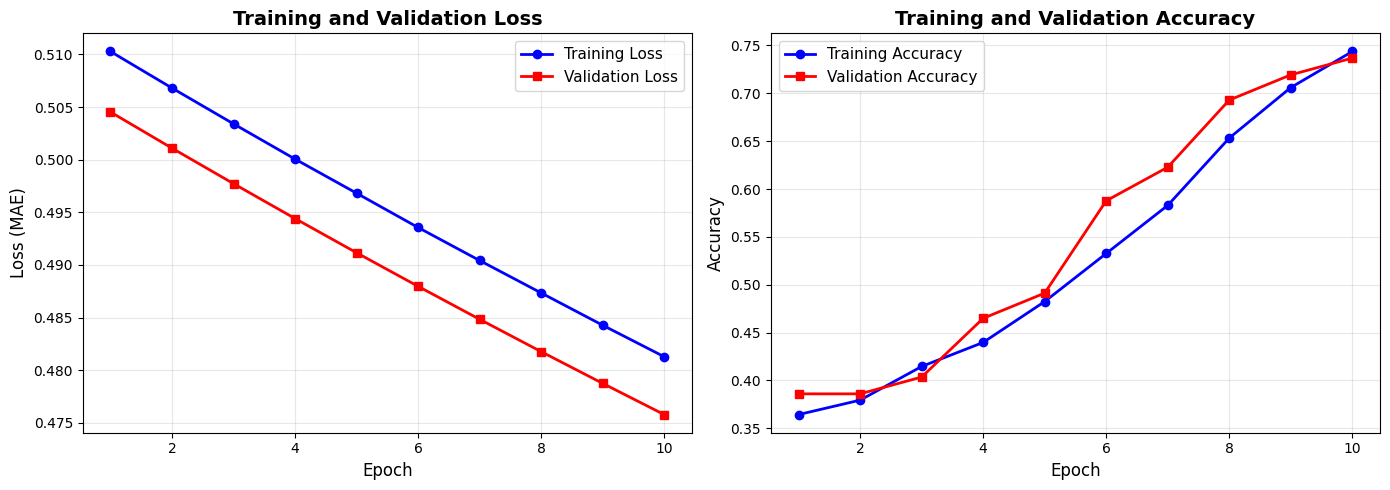

✓ Training curves plotted


In [22]:
# Requirement Name: Graphical Reporting - Loss Curves
# ====================================================

plt.figure(figsize=(14, 5))

# Plot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(range(1, len(nn.train_losses) + 1), nn.train_losses, 
         'b-o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(range(1, len(nn.val_losses) + 1), nn.val_losses, 
         'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MAE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(range(1, len(nn.train_accuracies) + 1), nn.train_accuracies, 
         'b-o', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(range(1, len(nn.val_accuracies) + 1), nn.val_accuracies, 
         'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training curves plotted")

In [23]:
# Requirement Name: Final Results - Testing Set Evaluation
# =========================================================

print("\n" + "=" * 80)
print("FINAL TESTING EVALUATION")
print("=" * 80)

# Prepare test data
test_data = [X_test, y_test]

# Test the network
test_error_vector, test_error = test_TestSet_np(test_data, nn)
test_predictions, _ = nn.forward_pass(X_test)
test_accuracy = accuracy_np(test_predictions, y_test)

print(f"\nTest Set Results:")
print(f"  Test Loss (MAE): {test_error:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  Test Error Rate: {1 - test_accuracy:.4f}")
print("=" * 80)


FINAL TESTING EVALUATION

Test Set Results:
  Test Loss (MAE): 0.4794
  Test Accuracy: 0.6842
  Test Error Rate: 0.3158


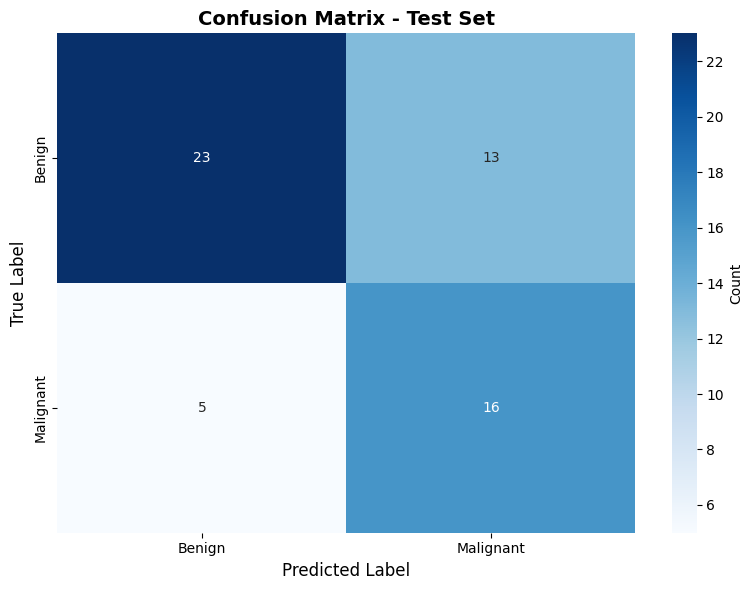

✓ Confusion matrix generated

Additional Metrics:
  Precision: 0.5517
  Recall: 0.7619
  F1-Score: 0.6400


In [24]:
# Requirement Name: Confusion Matrix Visualization
# =================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
test_predictions_prob, _ = nn.forward_pass(X_test)
test_predictions_class = (test_predictions_prob >= 0.5).astype(int).flatten()
y_test_class = y_test.flatten().astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test_class, test_predictions_class)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Confusion matrix generated")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1_score:.4f}")

In [25]:
# Requirement Name: Final Summary Report
# =======================================

print("\n" + "=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset Information:")
print(f"  Total samples: {len(df)}")
print(f"  Features: {X_train.shape[1]}")
print(f"  Classes: {n_classes}")

print(f"\n🏗️  Network Architecture:")
print(f"  Input neurons: {nn.input_size}")
print(f"  Hidden neurons: {nn.hidden_size}")
print(f"  Output neurons: {nn.output_size}")
print(f"  Activation function: {nn.activation_name}")
print(f"  Learning rate: {nn.learning_rate}")

print(f"\n📈 Training Configuration:")
print(f"  Training samples: {len(X_train)} (70%)")
print(f"  Validation samples: {len(X_val)} (20%)")
print(f"  Test samples: {len(X_test)} (10%)")
print(f"  Epochs: {len(nn.train_losses)}")
print(f"  Batch size: 100")

print(f"\n🎯 Final Performance:")
print(f"  Training Accuracy: {nn.train_accuracies[-1]:.4f}")
print(f"  Validation Accuracy: {nn.val_accuracies[-1]:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  Test Loss: {test_error:.4f}")

print("\n" + "=" * 80)
print("✓ PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)


FINAL PROJECT SUMMARY

📊 Dataset Information:
  Total samples: 569
  Features: 30
  Classes: 2

🏗️  Network Architecture:
  Input neurons: 30
  Hidden neurons: 10
  Output neurons: 1
  Activation function: sigmoid
  Learning rate: 0.01

📈 Training Configuration:
  Training samples: 398 (70%)
  Validation samples: 114 (20%)
  Test samples: 57 (10%)
  Epochs: 10
  Batch size: 100

🎯 Final Performance:
  Training Accuracy: 0.7437
  Validation Accuracy: 0.7368
  Test Accuracy: 0.6842
  Test Loss: 0.4794

✓ PROJECT COMPLETED SUCCESSFULLY
